# 06. Analiza prețurilor de producător pe datele integrate

**Proiect:** Integrarea probabilistă a registrelor farmaceutice oficiale din Republica Moldova și analiza prețurilor medicamentelor echivalente.
**Autor:** Olesea Popa, grupa SD251M, UTM.

Notebook-ul 05 a legat lista CNAM a medicamentelor compensate de Nomenclatorul AMDM. Prin codul medicamentului, fiecare produs legat primește acum prețul din Catalogul național de prețuri, iar fiecare produs din Catalog știe dacă este sau nu compensat. Pe aceste date integrate răspundem la trei întrebări. Prima este cât de mult diferă prețurile între medicamentele echivalente. A doua este dacă medicamentele compensate sunt mai ieftine decât echivalentele lor necompensate. A treia este dacă prețurile sunt mai împrăștiate acolo unde concurează mai multe firme, ca efect real și nu doar ca efect mecanic al numărului mai mare de prețuri.

Toate prețurile sunt prețuri de producător, adică prețul negociat dacă există, altfel prețul de producător din Catalog. Ele nu sunt prețurile plătite în farmacie, unde se adaugă adaosurile comerciale și TVA-ul, așa că nu tragem concluzii despre cât plătește pacientul. Analizăm doar formele solide, adică comprimatele, capsulele, drajeurile, supozitoarele și plicurile, pentru care prețul pe unitate este comparabil între ambalaje. Prețurile sunt modelate pe scară logaritmică, deoarece variază pe cinci ordine de mărime. Codul se află în fișierul src/prices.py.

## 0. Pregătirea mediului

**Ce căutăm.** Încărcăm Catalogul de prețuri, lista CNAM legată de Nomenclator în notebook-ul 05 și construim tabelul produselor solide cu prețul pe unitate, grupul de echivalență, deținătorul și indicatorul compensat.

In [1]:
import sys, logging, warnings
from pathlib import Path
import numpy as np                 # calcule numerice
import pandas as pd                # tabele de date
import matplotlib.pyplot as plt    # grafice
import seaborn as sns              # grafice statistice, peste matplotlib
import arviz as az                 # diagnosticul eșantionării bayesiene
from scipy.stats import spearmanr  # corelația Spearman

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore")
import pymc                        # modelele bayesiene (eșantionare NUTS)
logging.getLogger("pymc").setLevel(logging.ERROR)   # fără mesajele tehnice ale eșantionării

from normalize import country_set
from prices import (price_table, group_stats, mechanical_null, pooled_sigma, mixed_groups, fixed_effects_delta,
                    cluster_bootstrap_fe, bayes_compensated, bayes_dispersion, SEED)

FIG = ROOT / "reports" / "figures"
INTERIM, PROCESSED = ROOT / "data" / "interim", ROOT / "data" / "processed"
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight"})
pd.set_option("display.max_colwidth", 60, "display.width", 200)

cat = pd.read_csv(INTERIM / "catalog_norm.csv", dtype={"cod": str})
linked = pd.read_csv(PROCESSED / "cnam_legat_nomenclator.csv", dtype={"cod_nomenclator": str})
d = price_table(cat, linked, country_set(cat.tara))

def post(idata, var):
    # eșantioanele a posteriori ale unui parametru, din toate lanțurile
    return idata.posterior[var].values.reshape(-1)

print(f"Produse în Catalog: {len(cat)}; produse solide cu preț pe unitate: {len(d)}, dintre care compensate: {d.compensat.sum()}")
print(f"Tipul prețului: {d.tip_pret.value_counts().to_dict()}")

Produse în Catalog: 3719; produse solide cu preț pe unitate: 1929, dintre care compensate: 723
Tipul prețului: {'producator': 1769, 'negociat': 160}


**Ce am obținut.** Din cele 3.719 produse ale Catalogului, 1.929 sunt forme solide cu un preț pe unitate, iar 723 dintre ele sunt compensate, adică au fost legate de lista CNAM. Pentru 1.769 de produse prețul este prețul de producător, iar pentru 160 este prețul negociat.

## 1. Dispersia prețurilor între medicamentele echivalente

**Ce căutăm.** Pentru fiecare grup de echivalență cu cel puțin două produse calculăm raportul dintre cel mai mare și cel mai mic preț pe unitate. Un raport de 2 înseamnă că cel mai scump produs costă de două ori mai mult decât cel mai ieftin, deși este echivalent. Comparăm toate grupurile de forme solide din Catalog cu grupurile formate doar din produse compensate, adică dispersia pe care o vede sistemul de compensare.

In [2]:
g = group_stats(d)                                         # toate grupurile solide cu >= 2 produse
gc = group_stats(d[d.compensat])                           # doar produsele compensate
def describe(x):
    return {"grupuri": len(x), "produse": int(x.n.sum()), "raport median": x.raport.median(),
            "% grupuri cu raport >= 1,5": (x.raport >= 1.5).mean() * 100,
            "% grupuri cu raport >= 2": (x.raport >= 2).mean() * 100,
            "raport maxim": x.raport.max()}
disp = pd.DataFrame({"toate formele solide": describe(g), "doar compensate": describe(gc)})
print(disp.round(2).to_string())
print("\nGrupurile compensate cu cel mai mare raport:")
top = gc.sort_values("raport", ascending=False).head(8)
print(top[["n", "detinatori", "raport"]].round(2).to_string())

                            toate formele solide  doar compensate
grupuri                                   359.00           151.00
produse                                  1270.00           573.00
raport median                               1.30             1.35
% grupuri cu raport >= 1,5                 35.38            36.42
% grupuri cu raport >= 2                   18.38            18.54
raport maxim                               10.68             7.82

Grupurile compensate cu cel mai mare raport:
                                                 n  detinatori  raport
grup                                                                  
ambroxolum | 30 mg | comprimate                 11          11    7.82
omeprazolum | 20 mg | capsule gastrorezistente   6           6    5.51
ibuprofenum | 400 mg | comprimate filmate        8           8    4.80
ibuprofenum | 200 mg | comprimate filmate        4           4    4.26
bisoprololum | 5 mg | comprimate                 3           3    

**Ce am obținut.** Formele solide formează 359 de grupuri de echivalență cu cel puțin două produse, în total 1.270 de produse. Raportul median dintre cel mai mare și cel mai mic preț pe unitate este 1,30. În 35% dintre grupuri cel mai scump produs costă de cel puțin 1,5 ori mai mult decât cel mai ieftin, iar în 18% de cel puțin două ori mai mult. Grupurile formate doar din produse compensate sunt 151 și cuprind 573 de produse. Dispersia lor este practic aceeași, cu un raport median de 1,35 și 19% grupuri cu raportul de cel puțin 2. Cele mai mari diferențe între produse compensate apar la ambroxol 30 mg comprimate, unde 11 deținători au prețuri care diferă de până la 7,8 ori, la omeprazol 20 mg capsule, de 5,5 ori, și la ibuprofen 400 mg comprimate filmate, de 4,8 ori.

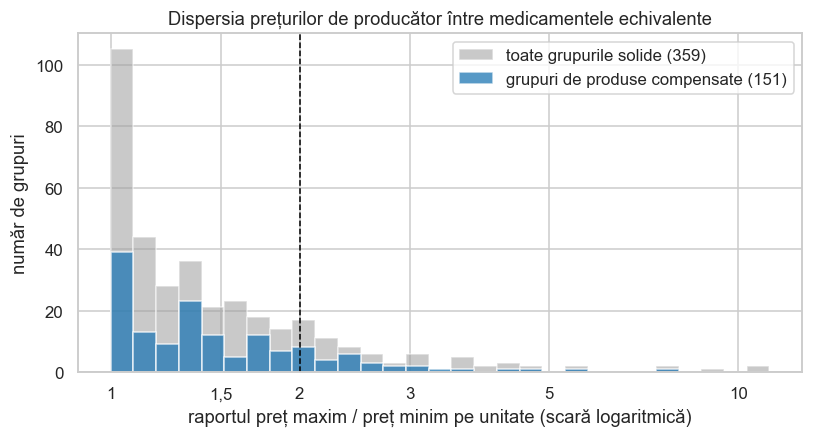

In [3]:
# Figura 16: distribuția raportului max/min, toate grupurile și grupurile compensate
fig, ax = plt.subplots(figsize=(8.5, 4))
bins = np.logspace(0, np.log10(max(g.raport.max(), 2) * 1.05), 30)
ax.hist(g.raport, bins=bins, alpha=0.55, label=f"toate grupurile solide ({len(g)})", color="#9e9e9e")
ax.hist(gc.raport, bins=bins, alpha=0.75, label=f"grupuri de produse compensate ({len(gc)})", color="#1f77b4")
ax.set_xscale("log")
ticks = [1, 1.5, 2, 3, 5, 10]
ax.set_xticks(ticks); ax.set_xticklabels([str(t).replace(".", ",") for t in ticks]); ax.minorticks_off()
ax.set_xlabel("raportul preț maxim / preț minim pe unitate (scară logaritmică)")
ax.set_ylabel("număr de grupuri"); ax.axvline(2, color="black", ls="--", lw=1)
ax.set_title("Dispersia prețurilor de producător între medicamentele echivalente")
ax.legend()
fig.savefig(FIG / "fig16_dispersie_echivalente.png")
plt.show()

**Ce am obținut.** Figura 16 arată că majoritatea grupurilor au diferențe mici, sub 1,5 ori, dar distribuția are o coadă lungă, cu grupuri în care prețurile echivalentelor diferă de 5 până la 10 ori. Grupurile compensate urmează aceeași formă ca toate grupurile.

**Constatare 1.** Între medicamentele echivalente în formă solidă, adică aceeași substanță, doză și formă, prețul de producător pe unitate diferă în mediană de 1,3 ori, iar în aproximativ unul din cinci grupuri de cel puțin două ori. Lista medicamentelor compensate nu reduce această dispersie. Grupurile formate doar din produse compensate au un raport median de 1,35, iar 19% dintre ele au o diferență de cel puțin două ori.

## 2. Sunt medicamentele compensate mai ieftine decât echivalentele lor?

**Ce căutăm.** Comparăm prețurile doar în interiorul aceluiași grup de echivalență, ca să nu amestecăm substanțe cu niveluri de preț foarte diferite. Folosim grupurile care conțin atât produse compensate, cât și necompensate. Estimăm diferența medie de log(preț) dintre un produs compensat și unul necompensat din același grup, notată delta, în două feluri. Varianta frecventistă folosește efecte fixe de grup, adică regresia pe abaterile de la media grupului, iar intervalul de încredere se obține prin bootstrap pe grupuri. Varianta bayesiană este un model ierarhic în care fiecare grup are nivelul lui de preț, iar nivelurile grupurilor provin dintr-o distribuție comună, așa că grupurile mici împrumută informație de la celelalte. Diferența procentuală de preț este exp(delta) minus 1.

In [4]:
m = mixed_groups(d)
print(f"Grupuri mixte: {m.grup.nunique()}; produse: {len(m)}, dintre care compensate: {m.compensat.sum()}")

delta_fe = fixed_effects_delta(m)
boot = cluster_bootstrap_fe(m, n_boot=2000, seed=SEED)
_, idc = bayes_compensated(m, draws=2000, tune=2000, chains=4, seed=SEED)
dpost = post(idc, "delta")
summ = az.summary(idc, var_names=["delta", "mu", "tau", "sigma"])
print("\nDiagnostic (R-hat aproape de 1 și ESS mare = lanțuri convergente):")
print(summ[["mean", "sd", "ess_bulk", "r_hat"]].to_string())
print(f"Divergențe: {int(idc.sample_stats['diverging'].values.sum())}")

pct = lambda x: (np.exp(x) - 1) * 100
comp = pd.DataFrame({
    "frecventist (efecte fixe + bootstrap pe grupuri)": [pct(delta_fe), pct(np.percentile(boot, 2.5)), pct(np.percentile(boot, 97.5)), np.nan],
    "bayesian (model ierarhic)": [pct(np.median(dpost)), pct(np.percentile(dpost, 2.5)), pct(np.percentile(dpost, 97.5)), (dpost < 0).mean()],
}, index=["diferența de preț (%)", "limita inferioară 95%", "limita superioară 95%", "P(compensat mai ieftin)"]).T
comp.round(3)

Grupuri mixte: 52; produse: 307, dintre care compensate: 211



Diagnostic (R-hat aproape de 1 și ESS mare = lanțuri convergente):
         mean      sd ess_bulk r_hat
delta  -0.076   0.049     9482  1.00
mu       0.89   0.141      622  1.01
tau     0.929   0.099      946  1.00
sigma  0.3785  0.0171     8665  1.00
Divergențe: 0


,diferența de preț (%),limita inferioară 95%,limita superioară 95%,P(compensat mai ieftin)
frecventist (efecte fixe + bootstrap pe grupuri),-7.189,-17.654,4.401,NaN
bayesian (model ierarhic),-7.337,-15.767,2.057,0.941


**Ce am obținut.** 52 de grupuri conțin atât produse compensate, cât și necompensate, cu 307 produse, dintre care 211 compensate. Ambele metode dau același rezultat. Un produs compensat are un preț pe unitate cu aproximativ 7% mai mic decât un echivalent necompensat din același grup, 7,2% după metoda frecventistă și aproximativ 7,3% după cea bayesiană, cu mici variații de la o rulare la alta. Incertitudinea este însă mare. Intervalul de încredere frecventist merge de la o scădere de 17,7% la o creștere de 4,4%, iar intervalul credibil bayesian de la o scădere de aproximativ 16% la o creștere de aproximativ 2%. Probabilitatea a posteriori ca produsele compensate să fie mai ieftine este 0,94. Lanțurile bayesiene au convers, cu R-hat egal cu 1,00 sau 1,01, câteva sute până la câteva mii de eșantioane efective și nicio divergență. Cu același seed, valorile bayesiene pot diferi foarte puțin de la o rulare la alta, cu câteva zecimi de punct procentual la limitele intervalului, din cauza erorilor de rotunjire amplificate de eșantionare. Diferențele rămân sub eroarea Monte Carlo și nu schimbă concluzia, de aceea raportăm valorile rotunjite.

**Ce căutăm.** Verificăm dacă rezultatul depinde de două surse de îndoială. Prima este legătura probabilistă. Unele produse sunt marcate compensate printr-o legătură marcată pentru verificare manuală, iar pe acestea le scoatem. A doua este tipul prețului. Prețurile negociate cu statul ar putea fi mai mici prin construcție, iar ele apar mai des la produsele compensate, așa că scoatem produsele cu preț negociat. Pentru rapiditate folosim estimatorul frecventist.

In [5]:
def fe_row(x, label):
    mx = mixed_groups(x)
    b = cluster_bootstrap_fe(mx, n_boot=2000, seed=SEED)
    return {"varianta": label, "grupuri": mx.grup.nunique(), "produse": len(mx),
            "diferența (%)": pct(fixed_effects_delta(mx)),
            "IC 95% inf (%)": pct(np.percentile(b, 2.5)), "IC 95% sup (%)": pct(np.percentile(b, 97.5))}
sens = pd.DataFrame([
    fe_row(d, "principală"),
    fe_row(d[~(d.compensat & d.de_verificat.fillna(False).astype(bool))], "fără legăturile de verificat"),
    fe_row(d[d.tip_pret == "producator"], "fără prețurile negociate"),
]).set_index("varianta")
sens.round(2)

,grupuri,produse,diferența (%),IC 95% inf (%),IC 95% sup (%)
varianta,,,,,
principală,52,307,-7.19,-17.65,4.40
fără legăturile de verificat,51,293,-7.60,-18.49,4.18
fără prețurile negociate,49,296,-8.14,-19.50,3.54


**Ce am obținut.** Rezultatul nu se schimbă în variantele de control. Fără produsele legate printr-o legătură marcată pentru verificare, diferența este de 7,6%, iar fără produsele cu preț negociat este de 8,1%. În ambele cazuri intervalul de încredere include zero.

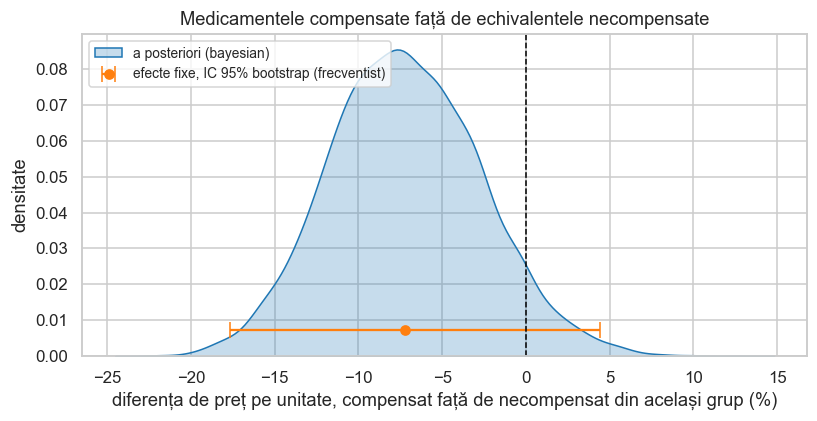

In [6]:
# Figura 17: distribuția a posteriori a diferenței de preț compensat – necompensat, cu intervalul frecventist
fig, ax = plt.subplots(figsize=(8.5, 3.8))
sns.kdeplot(pct(dpost), fill=True, color="#1f77b4", ax=ax, label="a posteriori (bayesian)")
lo, hi = pct(np.percentile(boot, [2.5, 97.5]))
ax.errorbar(pct(delta_fe), ax.get_ylim()[1] * 0.08, xerr=[[pct(delta_fe) - lo], [hi - pct(delta_fe)]], fmt="o",
            color="#ff7f0e", capsize=5, label="efecte fixe, IC 95% bootstrap (frecventist)")
ax.axvline(0, color="black", lw=1, ls="--")
ax.set_xlabel("diferența de preț pe unitate, compensat față de necompensat din același grup (%)")
ax.set_ylabel("densitate"); ax.legend(loc="upper left", fontsize=9)
ax.set_title("Medicamentele compensate față de echivalentele necompensate")
fig.savefig(FIG / "fig17_compensat_necompensat.png")
plt.show()

**Ce am obținut.** Figura 17 arată distribuția a posteriori a diferenței de preț, centrată în jurul unei scăderi de 7%, cu cea mai mare parte a masei sub zero. Intervalul frecventist, desenat dedesubt, are același centru și este puțin mai larg.

**Constatare 2.** În interiorul aceluiași grup de echivalență, medicamentele compensate au un preț de producător pe unitate cu aproximativ 7% mai mic decât echivalentele necompensate, cu o probabilitate a posteriori de 0,94 ca diferența să fie negativă. Pe cele 52 de grupuri disponibile, intervalele de 95% ale ambelor metode includ totuși zero, deci diferența nu este stabilită ferm. Rezultatul rămâne același fără legăturile nesigure și fără prețurile negociate.

## 3. Concurența și dispersia prețurilor: efect real sau mecanic?

**Ce căutăm.** Analiza exploratorie a arătat că raportul max/min crește cu numărul de deținători din grup. O parte din această legătură este însă mecanică. Grupurile cu mai mulți deținători au și mai multe produse, iar cu cât ai mai multe prețuri, cu atât cel mai mare și cel mai mic se depărtează, chiar dacă prețurile ar fi trase la întâmplare din aceeași distribuție. Măsurăm mai întâi partea mecanică. Presupunem că toate grupurile au aceeași dispersie, egală cu dispersia comună estimată din date, simulăm de 1.000 de ori prețurile fiecărui grup păstrând numărul lui de produse și calculăm corelația Spearman dintre numărul de deținători și raportul max/min simulat. Dacă cea observată se află în intervalul celor simulate, legătura poate fi explicată mecanic.

In [7]:
sigma0 = pooled_sigma(d, g.index)
null = mechanical_null(g, sigma0, n_sim=1000, seed=SEED)                 # rapoarte simulate: simulări × grupuri
rho_obs = spearmanr(g.detinatori, g.raport)[0]
rho_null = np.array([spearmanr(g.detinatori, r)[0] for r in null])
rho_sd = spearmanr(g.detinatori, g.sd)[0]
print(f"Dispersia comună (abaterea standard a log-prețului în grup): {sigma0:.3f}")
print(f"Spearman deținători – raport max/min: observat {rho_obs:.3f}; "
      f"doar efect mecanic {rho_null.mean():.3f} (95%: {np.percentile(rho_null, 2.5):.3f}–{np.percentile(rho_null, 97.5):.3f})")
print(f"Spearman deținători – abaterea standard a log-prețului (nu crește mecanic cu n): {rho_sd:.3f}")
buckets = pd.cut(g.detinatori, [0, 1, 2, 4, 100], labels=["1", "2", "3–4", "5+"])
null_med = pd.DataFrame(null.T, index=g.index).groupby(buckets.values).median()  # mediana raportului în fiecare simulare
tab = pd.DataFrame({"grupuri": g.groupby(buckets).size(),
                    "produse (median)": g.groupby(buckets).n.median(),
                    "raport median observat": g.groupby(buckets).raport.median(),
                    "raport median, doar mecanic": null_med.median(axis=1).values,
                    "mecanic 95% inf": null_med.quantile(0.025, axis=1).values,
                    "mecanic 95% sup": null_med.quantile(0.975, axis=1).values,
                    "abaterea standard mediană": g.groupby(buckets).sd.median()})
tab.round(3)

Dispersia comună (abaterea standard a log-prețului în grup): 0.302
Spearman deținători – raport max/min: observat 0.546; doar efect mecanic 0.474 (95%: 0.395–0.544)
Spearman deținători – abaterea standard a log-prețului (nu crește mecanic cu n): 0.409


,grupuri,produse (median),raport median observat,"raport median, doar mecanic",mecanic 95% inf,mecanic 95% sup,abaterea standard mediană
detinatori,,,,,,,
1,89,2.0,1.071,1.376,1.294,1.489,0.049
2,138,2.0,1.237,1.416,1.337,1.504,0.147
3–4,76,4.0,1.512,1.767,1.645,1.915,0.183
5+,56,7.0,2.037,2.286,2.106,2.482,0.258


**Ce am obținut.** Corelația Spearman observată dintre numărul de deținători și raportul max/min este 0,546. Dacă toate grupurile ar avea aceeași dispersie, corelația ar fi în medie 0,474, cu un interval de la 0,395 la 0,544, doar din cauza numărului mai mare de produse. Valoarea observată se află chiar la marginea superioară a acestui interval, deci cea mai mare parte a corelației poate fi explicată mecanic. Tabelul arată însă că raportul observat crește mai repede decât cel mecanic. De la grupurile cu un deținător la cele cu cinci sau mai mulți, raportul median observat crește de la 1,07 la 2,04, adică de 1,9 ori, iar cel mecanic de 1,66 ori. Abaterea standard a log-prețului, care nu crește mecanic cu numărul de produse, urcă de la 0,05 în grupurile cu un singur deținător la 0,26 în cele cu cinci sau mai mulți. Corelația ei cu numărul de deținători este 0,41.

**Ce căutăm.** Abaterea standard a log-prețului dintr-un grup nu crește mecanic cu numărul de produse, așa că o folosim ca măsură a dispersiei reale. Estimăm un model bayesian ierarhic în care fiecare grup are dispersia lui, sigma_j, iar logaritmul ei depinde liniar de logaritmul numărului de deținători, cu panta g1. Grupurile mici își estimează dispersia împrumutând informație de la celelalte. Media fiecărui grup este integrată analitic, așa că modelul folosește doar suma pătratelor abaterilor din fiecare grup. Diferențele de preț sub aproximativ 1% sunt tratate ca neglijabile. Dacă g1 este pozitiv, dispersia crește real cu numărul de firme, iar dublarea numărului de deținători înmulțește dispersia cu 2 la puterea g1.

In [8]:
_, idd = bayes_dispersion(d, g, draws=2000, tune=2000, chains=4, seed=SEED)
print("Diagnostic:")
print(az.summary(idd, var_names=["g0", "g1", "s"])[["mean", "sd", "ess_bulk", "r_hat"]].to_string())
print(f"Divergențe: {int(idd.sample_stats['diverging'].values.sum())}")
g1 = post(idd, "g1")
print(f"\ng1: mediana {np.median(g1):.3f}, interval credibil 95%: {np.percentile(g1, 2.5):.3f}–{np.percentile(g1, 97.5):.3f}; "
      f"P(g1 > 0) = {(g1 > 0).mean():.4f}")
print(f"Dublarea numărului de deținători înmulțește dispersia cu {2 ** np.median(g1):.2f} "
      f"(95%: {2 ** np.percentile(g1, 2.5):.2f}–{2 ** np.percentile(g1, 97.5):.2f})")

Diagnostic:
      mean     sd ess_bulk r_hat
g0  -2.531  0.126     1150  1.00
g1   0.621  0.104      764  1.00
s     1.07  0.077     1435  1.00
Divergențe: 0

g1: mediana 0.621, interval credibil 95%: 0.417–0.831; P(g1 > 0) = 1.0000
Dublarea numărului de deținători înmulțește dispersia cu 1.54 (95%: 1.34–1.78)


**Ce am obținut.** Modelul a convers, cu R-hat 1,00, câteva sute de eșantioane efective pentru fiecare parametru și nicio divergență. Panta g1 are mediana 0,62, cu un interval credibil de 95% de la 0,42 la 0,83, iar probabilitatea a posteriori ca ea să fie pozitivă este practic 1. Dublarea numărului de deținători dintr-un grup înmulțește dispersia tipică a prețurilor cu 1,54, cu un interval de la 1,34 la 1,78.

**Ce căutăm.** Verificăm dacă rezultatul depinde de pragul de 1% sub care diferențele de preț sunt considerate neglijabile. Reestimăm modelul cu pragurile de 0,5% și 2%.

In [9]:
rows = [{"prag": "1% (principal)", "g1 median": np.median(g1), "95% inf": np.percentile(g1, 2.5), "95% sup": np.percentile(g1, 97.5)}]
for fl in [0.005, 0.02]:
    _, idf = bayes_dispersion(d, g, draws=2000, tune=2000, chains=4, seed=SEED, floor=fl)
    gf = post(idf, "g1")
    rows.append({"prag": f"{fl:.1%}", "g1 median": np.median(gf), "95% inf": np.percentile(gf, 2.5),
                 "95% sup": np.percentile(gf, 97.5)})
pd.DataFrame(rows).set_index("prag").round(3)

,g1 median,95% inf,95% sup
prag,,,
1% (principal),0.621,0.417,0.831
0.5%,0.673,0.449,0.895
2.0%,0.572,0.386,0.769


**Ce am obținut.** Panta g1 rămâne aproape aceeași pentru toate pragurile, între aproximativ 0,57 la pragul de 2% și 0,67 la pragul de 0,5%, iar toate intervalele sunt clar pozitive. Rezultatul nu depinde deci de această alegere tehnică.

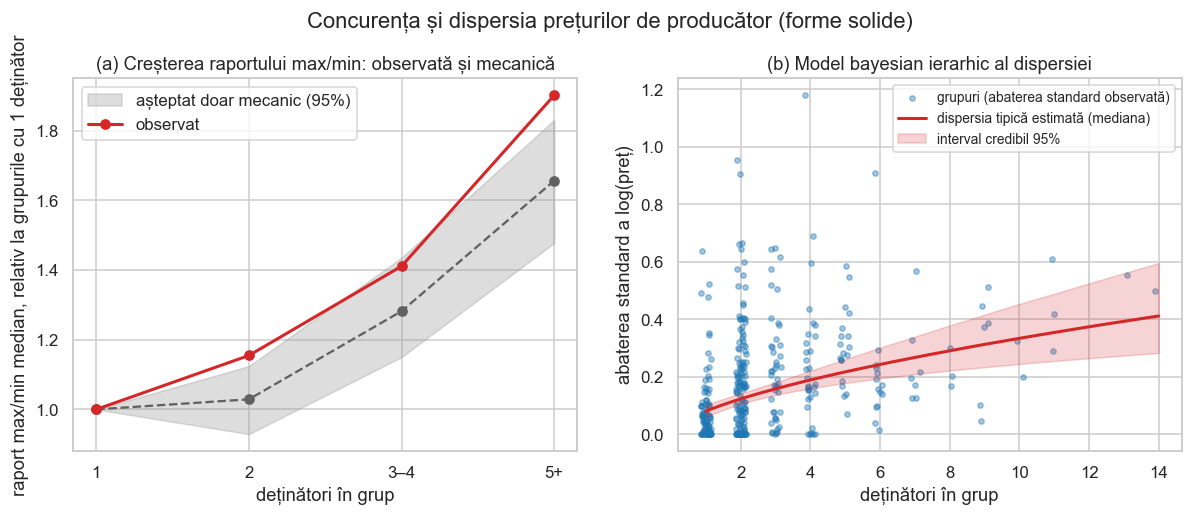

In [10]:
# Figura 18: (a) raportul max/min observat și cel așteptat doar mecanic; (b) dispersia estimată în funcție de deținători
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
# (a) creșterea raportului median față de grupurile cu un singur deținător (= 1), observată și doar mecanică;
# nivelul simulării mecanice depinde de dispersia comună aleasă, panta ei nu
x = np.arange(len(tab))
rel_null = null_med.div(null_med.iloc[0], axis=1)                 # fiecare simulare raportată la propriul grup „1”
axes[0].fill_between(x, rel_null.quantile(0.025, axis=1), rel_null.quantile(0.975, axis=1), color="#9e9e9e", alpha=0.35,
                     label="așteptat doar mecanic (95%)")
axes[0].plot(x, rel_null.median(axis=1), color="#616161", ls="--", marker="o")
axes[0].plot(x, tab["raport median observat"] / tab["raport median observat"].iloc[0], color="#d62728", marker="o", lw=2,
             label="observat")
axes[0].set_xticks(x); axes[0].set_xticklabels(tab.index)
axes[0].set_xlabel("deținători în grup"); axes[0].set_ylabel("raport max/min median, relativ la grupurile cu 1 deținător")
axes[0].set_title("(a) Creșterea raportului max/min: observată și mecanică"); axes[0].legend()

hh = np.linspace(1, g.detinatori.max(), 100)
g0 = post(idd, "g0")
curve = np.exp(g0[:, None] + g1[:, None] * np.log(hh)[None, :])
axes[1].scatter(g.detinatori + np.random.default_rng(SEED).uniform(-0.15, 0.15, len(g)), g.sd, s=12, alpha=0.4,
                color="#1f77b4", label="grupuri (abaterea standard observată)")
axes[1].plot(hh, np.median(curve, 0), color="#d62728", lw=2, label="dispersia tipică estimată (mediana)")
axes[1].fill_between(hh, np.percentile(curve, 2.5, 0), np.percentile(curve, 97.5, 0), color="#d62728", alpha=0.2,
                     label="interval credibil 95%")
axes[1].set_xlabel("deținători în grup"); axes[1].set_ylabel("abaterea standard a log(preț)")
axes[1].set_title("(b) Model bayesian ierarhic al dispersiei"); axes[1].legend(fontsize=9)
fig.suptitle("Concurența și dispersia prețurilor de producător (forme solide)", y=1.02)
fig.savefig(FIG / "fig18_concurenta_dispersie.png")
plt.show()

**Ce am obținut.** În figura 18a ambele curbe sunt raportate la grupurile cu un singur deținător. Curba observată crește mai repede decât cea așteptată doar mecanic și iese din banda ei la grupurile cu cinci sau mai mulți deținători. În figura 18b fiecare punct este un grup, iar curba roșie este dispersia tipică estimată de model. Ea crește de la aproximativ 0,08 pentru un deținător la aproximativ 0,4 pentru 14 deținători, iar banda arată incertitudinea. Multe grupuri cu unul sau doi deținători au dispersie aproape zero, adică prețuri identice pe unitate.

**Constatare 3.** Cea mai mare parte a legăturii dintre numărul de deținători și raportul max/min al prețurilor este un efect mecanic al numărului de produse. Corelația observată, de 0,55, este doar puțin peste cea așteptată mecanic, de 0,47. Măsurată prin abaterea standard, care nu depinde mecanic de numărul de produse, dispersia crește totuși real cu numărul de firme. Modelul bayesian ierarhic estimează că dublarea numărului de deținători înmulțește dispersia prețurilor de producător cu 1,54, cu un interval credibil de la 1,34 la 1,78. Mai multe firme pe aceeași piață înseamnă deci prețuri mai variate, nu prețuri aliniate.

## 4. Rezumat și limitări

Legarea listei CNAM de Nomenclator a permis analiza prețurilor de producător ale medicamentelor compensate. Între produsele echivalente în formă solidă, prețul pe unitate diferă în mediană de 1,3 ori, iar în aproximativ unul din cinci grupuri de cel puțin două ori, la fel pentru produsele compensate ca pentru toată piața. În interiorul aceluiași grup, produsele compensate sunt cu aproximativ 7% mai ieftine decât cele necompensate, dar diferența nu este stabilită ferm. Dispersia prețurilor crește real cu numărul de firme, chiar după separarea efectului mecanic al numărului de produse.

Limitele analizei trebuie menționate explicit. Prețurile sunt de producător, deci nu spun cât plătește pacientul în farmacie. Formele lichide au fost excluse, pentru că prețul lor ar trebui normalizat pe cantitatea de substanță. Analiza este transversală, pe un singur catalog de prețuri, deci arată asocieri, nu cauze. Legătura cu lista CNAM este probabilistă, deși verificarea fără legăturile nesigure nu schimbă rezultatele.

**Ce căutăm.** Salvăm tabelul grupurilor de echivalență cu statisticile de preț și indicatorul compensat, pentru articol și pentru aplicația mobilă din partea a doua a tezei.

In [11]:
out = g.join(gc[["n", "raport"]].rename(columns={"n": "n_compensate", "raport": "raport_compensate"}))
out.to_csv(PROCESSED / "grupuri_echivalenta_preturi.csv")
print(out.shape, list(out.columns))

(359, 9) ['n', 'detinatori', 'compensate', 'y_min', 'y_max', 'sd', 'raport', 'n_compensate', 'raport_compensate']


**Ce am obținut.** Tabelul grupuri_echivalenta_preturi.csv are 359 de rânduri, câte unul pentru fiecare grup de echivalență în formă solidă, cu numărul de produse și de deținători, numărul de produse compensate, prețurile minim și maxim pe scară logaritmică, abaterea standard și raportul max/min, atât pentru tot grupul, cât și doar pentru produsele compensate.